# Data Preparation FIVES Blood Vessel Segmentation

Struktur folder
```text
/content/drive/MyDrive/BV_CDR/
└── raw/
    ├── full-fundus/
    │   ├── FIVES-001.xxx
    │   ├── FIVES-002.xxx
    │   └── ...
    └── blood-vessel/
        ├── FIVES-001.xxx
        ├── FIVES-002.xxx
        └── ...
```

Output notebook ini:

```text
BV_CDR/
├── splits/
│   ├── all_pairs.csv
│   ├── train.csv
│   ├── val.csv
│   ├── test.csv
│   └── processed_pairs.csv
├── processed/
│   ├── images_512/{train,val,test}/
│   └── masks_512/{train,val,test}/
└── results/previews/dataprep/
```


In [ ]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import random
from pathlib import Path

BASE_DIR = Path('/content/drive/MyDrive/BV_CDR')
RAW_DIR = BASE_DIR / 'raw'
IMAGE_DIR = RAW_DIR / 'full-fundus'
MASK_DIR = RAW_DIR / 'blood-vessel'

IMG_SIZE = 512

#split data
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15


RANDOM_SEED = 42

VALID_EXTS = ['.png', '.jpg', '.jpeg', '.tif', '.tiff', '.bmp']

print('BASE_DIR :', BASE_DIR)
print('IMAGE_DIR:', IMAGE_DIR)
print('MASK_DIR :', MASK_DIR)


BASE_DIR : /content/drive/MyDrive/BV_CDR
IMAGE_DIR: /content/drive/MyDrive/BV_CDR/raw/full-fundus
MASK_DIR : /content/drive/MyDrive/BV_CDR/raw/blood-vessel


In [ ]:
assert BASE_DIR.exists(), f'BASE_DIR tidak ditemukan: {BASE_DIR}'
assert IMAGE_DIR.exists(), f'Folder full-fundus tidak ditemukan: {IMAGE_DIR}'
assert MASK_DIR.exists(), f'Folder blood-vessel tidak ditemukan: {MASK_DIR}'

print('Folder raw ditemukan dan siap dibaca.')


Folder raw ditemukan dan siap dibaca.


In [ ]:
OUTPUT_FOLDERS = [
    BASE_DIR / 'splits',
    BASE_DIR / 'processed' / f'images_{IMG_SIZE}' / 'train',
    BASE_DIR / 'processed' / f'images_{IMG_SIZE}' / 'val',
    BASE_DIR / 'processed' / f'images_{IMG_SIZE}' / 'test',
    BASE_DIR / 'processed' / f'masks_{IMG_SIZE}' / 'train',
    BASE_DIR / 'processed' / f'masks_{IMG_SIZE}' / 'val',
    BASE_DIR / 'processed' / f'masks_{IMG_SIZE}' / 'test',
    BASE_DIR / 'models' / 'unet',
    BASE_DIR / 'models' / 'attention_unet',
    BASE_DIR / 'results' / 'metrics',
    BASE_DIR / 'results' / 'plots',
    BASE_DIR / 'results' / 'previews' / 'dataprep',
    BASE_DIR / 'predictions' / 'fives_test' / 'masks_pred',
    BASE_DIR / 'predictions' / 'fives_test' / 'overlay',
    BASE_DIR / 'predictions' / 'refuge' / 'masks_pred',
    BASE_DIR / 'predictions' / 'refuge' / 'overlay',
]

for folder in OUTPUT_FOLDERS:
    folder.mkdir(parents=True, exist_ok=True)

print('Semua folder output berhasil dibuat.')


Semua folder output berhasil dibuat.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print('Library berhasil diimport.')


Library berhasil diimport.


In [ ]:
# baca data

def list_image_files(folder, valid_exts=VALID_EXTS):
    """Mengambil semua file gambar dari sebuah folder."""
    files = []
    for ext in valid_exts:
        files.extend(folder.glob(f'*{ext}'))
        files.extend(folder.glob(f'*{ext.upper()}'))
    return sorted(list(set(files)))


def stem_name(path):
    """Mengambil nama file tanpa ekstensi, misalnya FIVES-001."""
    return Path(path).stem


def build_file_dict(paths):
    """Membuat dictionary: nama_file_tanpa_ekstensi -> path."""
    return {stem_name(p): str(p) for p in paths}


In [ ]:
#cek jumlah data dan cocokan

image_paths = list_image_files(IMAGE_DIR)
mask_paths = list_image_files(MASK_DIR)

image_dict = build_file_dict(image_paths)
mask_dict = build_file_dict(mask_paths)

image_names = set(image_dict.keys())
mask_names = set(mask_dict.keys())

matched_names = sorted(list(image_names & mask_names))
missing_masks = sorted(list(image_names - mask_names))
missing_images = sorted(list(mask_names - image_names))

print('Jumlah fundus image     :', len(image_paths))
print('Jumlah vessel mask      :', len(mask_paths))
print('Jumlah pasangan cocok   :', len(matched_names))
print('Image tanpa mask        :', len(missing_masks))
print('Mask tanpa image        :', len(missing_images))

if missing_masks:
    print('Contoh image tanpa mask:')
    print(missing_masks[:10])

if missing_images:
    print('Contoh mask tanpa image:')
    print(missing_images[:10])

assert len(matched_names) > 0, 'Tidak ada pasangan image-mask yang cocok. Cek nama file dan struktur folder.'


Jumlah fundus image     : 400
Jumlah vessel mask      : 400
Jumlah pasangan cocok   : 400
Image tanpa mask        : 0
Mask tanpa image        : 0


In [ ]:
# creating csv

pairs = []
for name in matched_names:
    pairs.append({
        'filename': name,
        'image_path': image_dict[name],
        'mask_path': mask_dict[name]
    })

df_all = pd.DataFrame(pairs).sort_values('filename').reset_index(drop=True)

all_pairs_csv = BASE_DIR / 'splits' / 'all_pairs.csv'
df_all.to_csv(all_pairs_csv, index=False)

print('all_pairs.csv berhasil disimpan di:')
print(all_pairs_csv)
print('Contoh data:')
display(df_all.head())


all_pairs.csv berhasil disimpan di:
/content/drive/MyDrive/BV_CDR/splits/all_pairs.csv
Contoh data:


,filename,image_path,mask_path
0,FIVES-1,/content/drive/MyDrive/BV_CDR/raw/full-fundus/...,/content/drive/MyDrive/BV_CDR/raw/blood-vessel...
1,FIVES-10,/content/drive/MyDrive/BV_CDR/raw/full-fundus/...,/content/drive/MyDrive/BV_CDR/raw/blood-vessel...
2,FIVES-100,/content/drive/MyDrive/BV_CDR/raw/full-fundus/...,/content/drive/MyDrive/BV_CDR/raw/blood-vessel...
3,FIVES-101,/content/drive/MyDrive/BV_CDR/raw/full-fundus/...,/content/drive/MyDrive/BV_CDR/raw/blood-vessel...
4,FIVES-102,/content/drive/MyDrive/BV_CDR/raw/full-fundus/...,/content/drive/MyDrive/BV_CDR/raw/blood-vessel...


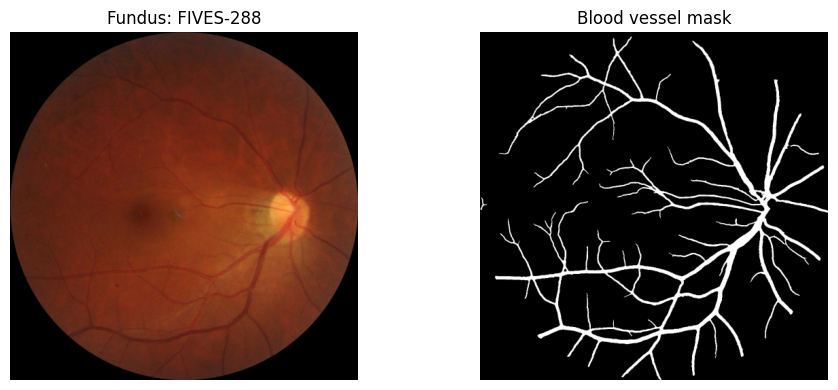

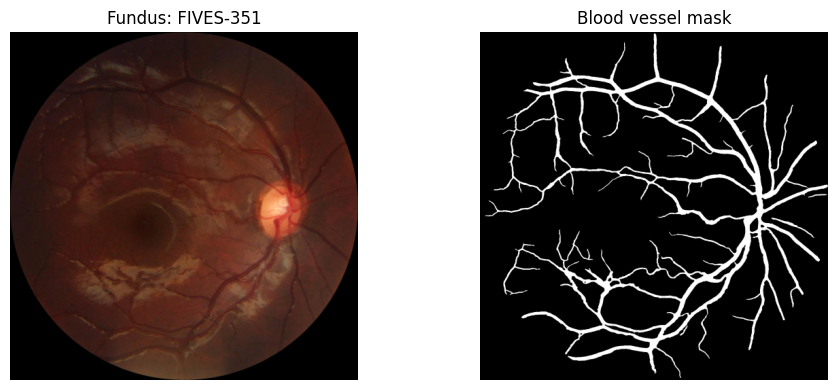

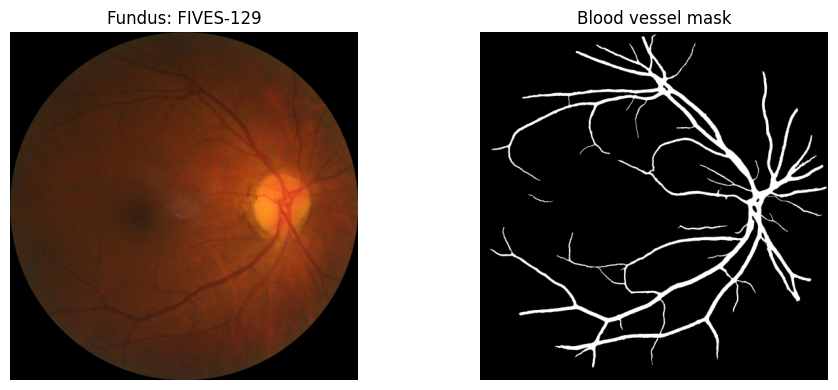

In [ ]:
# preview fundus dan GT

def load_rgb(path):
    return Image.open(path).convert('RGB')


def load_gray(path):
    return Image.open(path).convert('L')

sample_df = df_all.sample(n=min(3, len(df_all)), random_state=RANDOM_SEED)

for _, row in sample_df.iterrows():
    img = load_rgb(row['image_path'])
    mask = load_gray(row['mask_path'])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"Fundus: {row['filename']}")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Blood vessel mask')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
# Split train/val/test

# Split train dan temporary
train_df, temp_df = train_test_split(
    df_all,
    test_size=(1 - TRAIN_RATIO),
    random_state=RANDOM_SEED,
    shuffle=True
)

# Split temporary menjadi validation dan test
val_fraction_from_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)

val_df, test_df = train_test_split(
    temp_df,
    test_size=(1 - val_fraction_from_temp),
    random_state=RANDOM_SEED,
    shuffle=True
)

train_df = train_df.sort_values('filename').reset_index(drop=True)
val_df = val_df.sort_values('filename').reset_index(drop=True)
test_df = test_df.sort_values('filename').reset_index(drop=True)

print('Jumlah train:', len(train_df))
print('Jumlah val  :', len(val_df))
print('Jumlah test :', len(test_df))
print('Total       :', len(train_df) + len(val_df) + len(test_df))

train_csv = BASE_DIR / 'splits' / 'train.csv'
val_csv = BASE_DIR / 'splits' / 'val.csv'
test_csv = BASE_DIR / 'splits' / 'test.csv'

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)

print('CSV split berhasil disimpan:')
print(train_csv)
print(val_csv)
print(test_csv)


Jumlah train: 279
Jumlah val  : 60
Jumlah test : 61
Total       : 400
CSV split berhasil disimpan:
/content/drive/MyDrive/BV_CDR/splits/train.csv
/content/drive/MyDrive/BV_CDR/splits/val.csv
/content/drive/MyDrive/BV_CDR/splits/test.csv


In [ ]:
# fungsi preprocessing image dan mask

def preprocess_image(image_path, img_size=IMG_SIZE):
    """
    Membaca fundus image, convert RGB, lalu resize.
    Image disimpan sebagai RGB 8-bit.
    """
    image = Image.open(image_path).convert('RGB')
    image = ImageOps.exif_transpose(image)
    image = image.resize((img_size, img_size), Image.Resampling.LANCZOS)
    return image


def preprocess_mask(mask_path, img_size=IMG_SIZE, threshold=127):
    """
    Membaca vessel mask, convert grayscale, resize nearest neighbor,
    lalu binarisasi menjadi 0 dan 255.
    """
    mask = Image.open(mask_path).convert('L')
    mask = ImageOps.exif_transpose(mask)
    mask = mask.resize((img_size, img_size), Image.Resampling.NEAREST)
    mask_np = np.array(mask)
    mask_bin = (mask_np > threshold).astype(np.uint8) * 255
    return Image.fromarray(mask_bin, mode='L')


In [ ]:
# resize

def process_split(split_name, split_df):
    image_out_dir = BASE_DIR / 'processed' / f'images_{IMG_SIZE}' / split_name
    mask_out_dir = BASE_DIR / 'processed' / f'masks_{IMG_SIZE}' / split_name
    image_out_dir.mkdir(parents=True, exist_ok=True)
    mask_out_dir.mkdir(parents=True, exist_ok=True)

    records = []

    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f'Processing {split_name}'):
        filename = row['filename']
        out_image_path = image_out_dir / f'{filename}.png'
        out_mask_path = mask_out_dir / f'{filename}.png'

        image = preprocess_image(row['image_path'], IMG_SIZE)
        mask = preprocess_mask(row['mask_path'], IMG_SIZE)

        image.save(out_image_path)
        mask.save(out_mask_path)

        records.append({
            'filename': filename,
            'split': split_name,
            'image_path': str(out_image_path),
            'mask_path': str(out_mask_path)
        })

    return records

processed_records = []
processed_records.extend(process_split('train', train_df))
processed_records.extend(process_split('val', val_df))
processed_records.extend(process_split('test', test_df))

processed_df = pd.DataFrame(processed_records).sort_values(['split', 'filename']).reset_index(drop=True)
processed_csv = BASE_DIR / 'splits' / 'processed_pairs.csv'
processed_df.to_csv(processed_csv, index=False)

print('Preprocessing selesai.')
print('processed_pairs.csv berhasil disimpan di:')
print(processed_csv)
display(processed_df.head())


Processing train:   0%|          | 0/279 [00:00<?, ?it/s]

/tmp/ipykernel_2533/1637682312.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(mask_bin, mode='L')


Processing val:   0%|          | 0/60 [00:00<?, ?it/s]

Processing test:   0%|          | 0/61 [00:00<?, ?it/s]

Preprocessing selesai.
processed_pairs.csv berhasil disimpan di:
/content/drive/MyDrive/BV_CDR/splits/processed_pairs.csv


,filename,split,image_path,mask_path
0,FIVES-1,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
1,FIVES-103,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
2,FIVES-107,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
3,FIVES-121,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...
4,FIVES-127,test,/content/drive/MyDrive/BV_CDR/processed/images...,/content/drive/MyDrive/BV_CDR/processed/masks_...


In [ ]:
# Validasi hasil preprocessing

for split_name in ['train', 'val', 'test']:
    img_dir = BASE_DIR / 'processed' / f'images_{IMG_SIZE}' / split_name
    msk_dir = BASE_DIR / 'processed' / f'masks_{IMG_SIZE}' / split_name

    n_img = len(list(img_dir.glob('*.png')))
    n_msk = len(list(msk_dir.glob('*.png')))

    print(f'{split_name.upper()}')
    print('  images:', n_img)
    print('  masks :', n_msk)
    assert n_img == n_msk, f'Jumlah image dan mask tidak sama pada split {split_name}'

print('Validasi jumlah file processed aman.')


TRAIN
  images: 279
  masks : 279
VAL
  images: 60
  masks : 60
TEST
  images: 61
  masks : 61
Validasi jumlah file processed aman.


In [ ]:
# Cek nilai unik mask dan rasio vessel pixel

def mask_stats(mask_path):
    mask = np.array(Image.open(mask_path).convert('L'))
    unique_values = np.unique(mask)
    vessel_ratio = (mask > 0).mean()
    return unique_values, vessel_ratio

sample_processed = processed_df.sample(n=min(10, len(processed_df)), random_state=RANDOM_SEED)
ratios = []

for _, row in sample_processed.iterrows():
    unique_values, vessel_ratio = mask_stats(row['mask_path'])
    ratios.append(vessel_ratio)
    print(row['filename'], '| split:', row['split'], '| unique:', unique_values, '| vessel ratio:', round(vessel_ratio, 4))

print('Rata-rata vessel ratio pada sampel:', round(float(np.mean(ratios)), 4))


FIVES-292 | split: train | unique: [  0 255] | vessel ratio: 0.094
FIVES-383 | split: train | unique: [  0 255] | vessel ratio: 0.0814
FIVES-288 | split: test | unique: [  0 255] | vessel ratio: 0.0808
FIVES-293 | split: train | unique: [  0 255] | vessel ratio: 0.0889
FIVES-144 | split: train | unique: [  0 255] | vessel ratio: 0.0837
FIVES-132 | split: train | unique: [  0 255] | vessel ratio: 0.0739
FIVES-8 | split: train | unique: [  0 255] | vessel ratio: 0.0705
FIVES-145 | split: train | unique: [  0 255] | vessel ratio: 0.0793
FIVES-368 | split: train | unique: [  0 255] | vessel ratio: 0.079
FIVES-192 | split: train | unique: [  0 255] | vessel ratio: 0.0887
Rata-rata vessel ratio pada sampel: 0.082


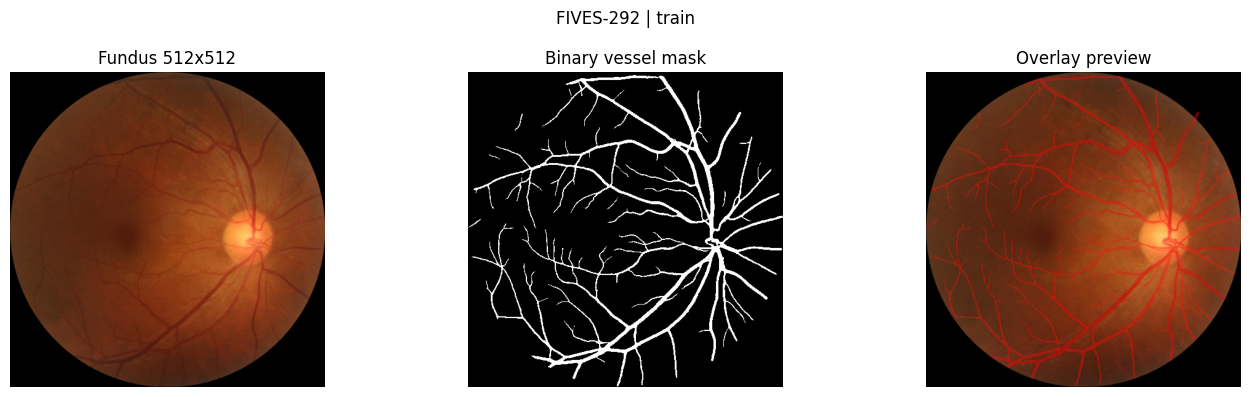

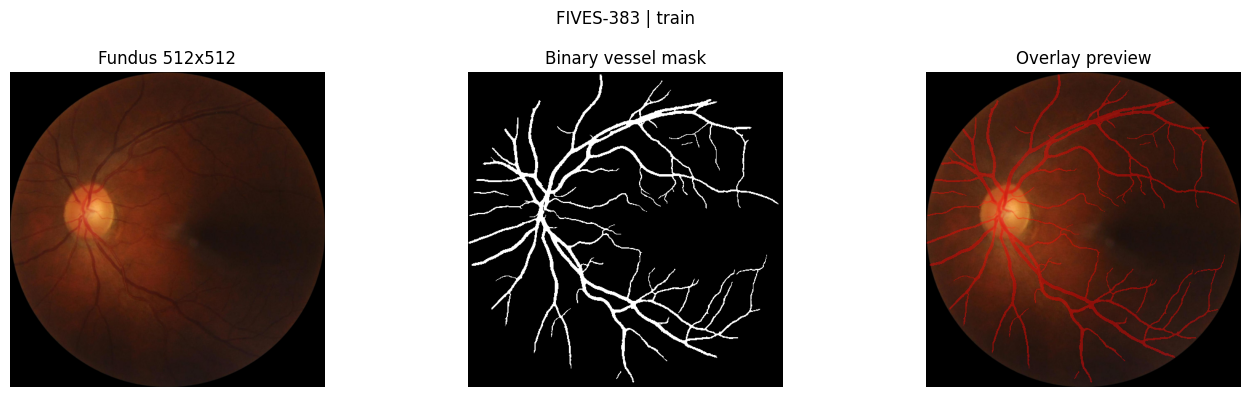

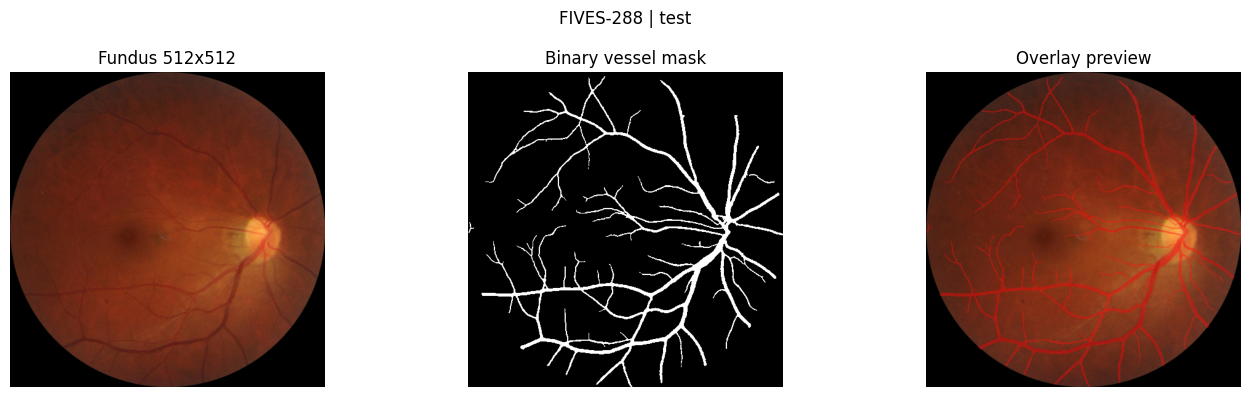

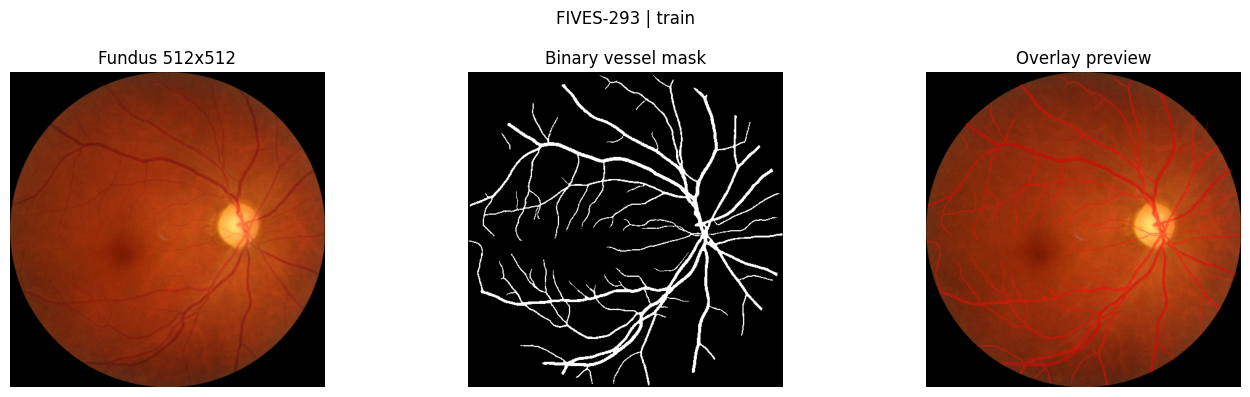

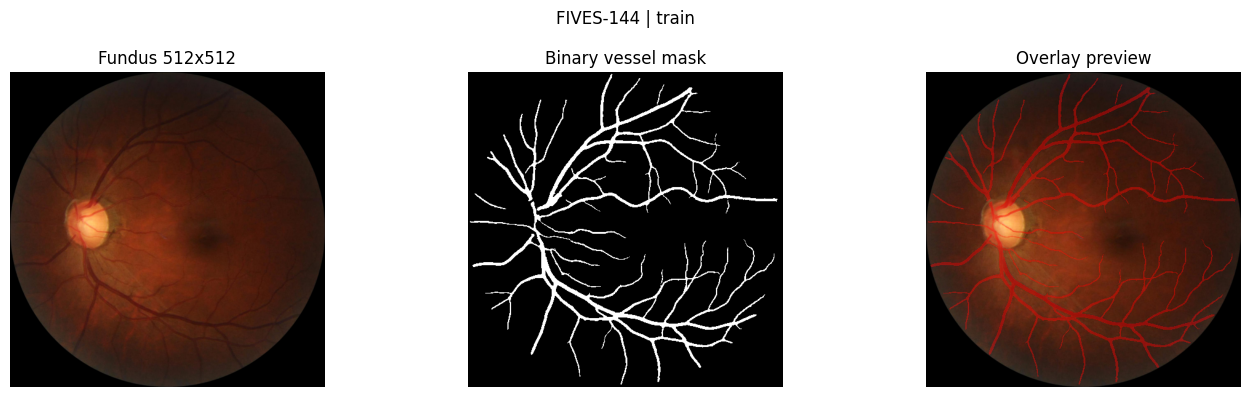

Preview disimpan di:
/content/drive/MyDrive/BV_CDR/results/previews/dataprep


In [ ]:
# Preview hasil processed fundus, mask, dan overlay

def make_overlay(image_np, mask_np, alpha=0.45):
    """
    Membuat overlay vessel mask di atas citra fundus.
    Overlay hanya untuk preview visual, bukan untuk training.
    """
    image = image_np.astype(np.float32).copy()
    mask_binary = mask_np > 0

    overlay = image.copy()
    # Marking vessel area dengan intensitas terang pada channel merah untuk visualisasi.
    overlay[mask_binary, 0] = 255
    overlay[mask_binary, 1] = overlay[mask_binary, 1] * (1 - alpha)
    overlay[mask_binary, 2] = overlay[mask_binary, 2] * (1 - alpha)

    blended = (image * (1 - alpha) + overlay * alpha).clip(0, 255).astype(np.uint8)
    return blended

preview_dir = BASE_DIR / 'results' / 'previews' / 'dataprep'
preview_dir.mkdir(parents=True, exist_ok=True)

sample_processed = processed_df.sample(n=min(5, len(processed_df)), random_state=RANDOM_SEED)

for _, row in sample_processed.iterrows():
    img = np.array(Image.open(row['image_path']).convert('RGB'))
    mask = np.array(Image.open(row['mask_path']).convert('L'))
    overlay = make_overlay(img, mask)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"Fundus {IMG_SIZE}x{IMG_SIZE}")
    axes[0].axis('off')

    axes[1].imshow(mask, cmap='gray')
    axes[1].set_title('Binary vessel mask')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Overlay preview')
    axes[2].axis('off')

    plt.suptitle(f"{row['filename']} | {row['split']}")
    plt.tight_layout()

    save_path = preview_dir / f"preview_{row['split']}_{row['filename']}.png"
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

print('Preview disimpan di:')
print(preview_dir)


In [ ]:
# ringkasan data prep

summary = {
    'base_dir': str(BASE_DIR),
    'image_dir_raw': str(IMAGE_DIR),
    'mask_dir_raw': str(MASK_DIR),
    'img_size': IMG_SIZE,
    'raw_pairs': len(df_all),
    'train': len(train_df),
    'val': len(val_df),
    'test': len(test_df),
    'processed_pairs_csv': str(processed_csv),
}

summary_df = pd.DataFrame([summary])
summary_csv = BASE_DIR / 'results' / 'metrics' / 'dataprep_summary.csv'
summary_df.to_csv(summary_csv, index=False)

display(summary_df)
print('Ringkasan data preparation disimpan di:')
print(summary_csv)

print('DATA PREPARATION SELESAI. Data siap untuk training U-Net / Attention U-Net.')


,base_dir,image_dir_raw,mask_dir_raw,img_size,raw_pairs,train,val,test,processed_pairs_csv
0,/content/drive/MyDrive/BV_CDR,/content/drive/MyDrive/BV_CDR/raw/full-fundus,/content/drive/MyDrive/BV_CDR/raw/blood-vessel,512,400,279,60,61,/content/drive/MyDrive/BV_CDR/splits/processed...


Ringkasan data preparation disimpan di:
/content/drive/MyDrive/BV_CDR/results/metrics/dataprep_summary.csv
DATA PREPARATION SELESAI. Data siap untuk training U-Net / Attention U-Net.



output file:

```text
/content/drive/MyDrive/BV_CDR/splits/processed_pairs.csv
```

Formatnya sudah berisi : filename, split, image_path, mask_path
